# Create RMG Thermo Library from DFT Data

In [1]:
import input_generator as ig
import os
import re
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'Data', 'Cu3Sn0001'))

In [4]:
def count_atoms(molecule_name):
    atom_counts = {'H': 0, 'C': 0, 'N': 0, 'O': 0, 'Cu3Sn': 0}

    # Replace 'X' with 'Cu3Sn' for counting purposes
    molecule_name = molecule_name.replace('X', 'Cu3Sn')

    # Regex to find elements and their counts
    pattern = re.compile(r'(Cu3Sn|H|C|N|O)(\d*)')

    # Find all matches
    matches = pattern.findall(molecule_name)

    for element, count in matches:
        count = int(count) if count else 1
        if element in atom_counts:
            atom_counts[element] += count

    return atom_counts

In [5]:
def create_composition_list(base_dir):
    compositions = {}

    # Iterate through all folders in the base directory
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)

        if os.path.isdir(folder_path):
            # Assume folder name is the molecule name
            molecule_name = folder_name

            # Count atoms in the molecule name
            atom_counts = count_atoms(molecule_name)

            # Store the composition
            compositions[molecule_name] = atom_counts

    return compositions

In [6]:
compositions = create_composition_list(base_dir)
print(compositions)

{'CHOX': {'H': 1, 'C': 1, 'N': 0, 'O': 1, 'Cu3Sn': 1}, 'COCHOX': {'H': 1, 'C': 2, 'N': 0, 'O': 2, 'Cu3Sn': 1}, 'COOHX': {'H': 1, 'C': 1, 'N': 0, 'O': 2, 'Cu3Sn': 1}, 'COX': {'H': 0, 'C': 1, 'N': 0, 'O': 1, 'Cu3Sn': 1}, 'OCCOX': {'H': 0, 'C': 2, 'N': 0, 'O': 2, 'Cu3Sn': 1}, 'OCH2CH3X': {'H': 5, 'C': 2, 'N': 0, 'O': 1, 'Cu3Sn': 1}, 'OCHCH2OHX': {'H': 4, 'C': 2, 'N': 0, 'O': 2, 'Cu3Sn': 1}, 'OCHCH2X': {'H': 3, 'C': 2, 'N': 0, 'O': 1, 'Cu3Sn': 1}, 'OCHCH3X': {'H': 4, 'C': 2, 'N': 0, 'O': 1, 'Cu3Sn': 1}, 'OCHCHOHX': {'H': 3, 'C': 2, 'N': 0, 'O': 2, 'Cu3Sn': 1}, 'OCHCHX': {'H': 2, 'C': 2, 'N': 0, 'O': 1, 'Cu3Sn': 1}, 'OCHOCHX': {'H': 2, 'C': 2, 'N': 0, 'O': 2, 'Cu3Sn': 1}, 'OCHOX': {'H': 1, 'C': 1, 'N': 0, 'O': 2, 'Cu3Sn': 1}}


In [7]:
def generate_traj_ps(base_dir):
    traj_ps = []

    # Iterate through all folders in the base directory
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)

        if os.path.isdir(folder_path):
            # Assume folder name is the molecule name
            molecule_name = folder_name

            # Define expected filenames
            files = [
                f'relax_restart_{molecule_name}.traj',
                f'zpe_log_{molecule_name}.txt',
                f'ads60_{molecule_name}.traj'
            ]

            # Generate absolute paths for the files
            abs_paths = [os.path.abspath(os.path.join(folder_path, file)) for file in files]

            # Check if all files exist
            missing_files = [file for file in files if not os.path.isfile(os.path.join(folder_path, file))]

            if missing_files:
                print(f"Error: Missing files in folder '{folder_name}': {', '.join(missing_files)}")
            else:
                # Append filenames to traj_ps if all files are present
                traj_ps.append(abs_paths)

    return traj_ps

In [8]:
traj_ps = generate_traj_ps(base_dir)
print(traj_ps)

[['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/CHOX/relax_restart_CHOX.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/CHOX/zpe_log_CHOX.txt', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/CHOX/ads60_CHOX.traj'], ['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COCHOX/relax_restart_COCHOX.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COCHOX/zpe_log_COCHOX.txt', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COCHOX/ads60_COCHOX.traj'], ['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COOHX/relax_restart_COOHX.traj', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COOHX/zpe_log_COOHX.txt', '/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COOHX/ads60_COOHX.traj'], ['/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Data/Cu3Sn0001/COX/relax_restart_COX.traj', '/projects/westgroup/asifor.t/C

In [9]:
output_p = "recalc_dft_sp"

In [10]:
ig.input_generation(compositions, traj_ps, output_p, ocp=False)

-22.86630841
The heat of formation at 0 K for CHOX is -105.94352505085176 kJ/mol
The heat of formation at 0 K for COCHOX is -239.6811769932164 kJ/mol
The heat of formation at 0 K for COOHX is -390.9643024097927 kJ/mol
The heat of formation at 0 K for COX is -154.0797004330051 kJ/mol
The heat of formation at 0 K for OCCOX is -210.85057720835937 kJ/mol
The heat of formation at 0 K for OCH2CH3X is -257.5579994450707 kJ/mol
The heat of formation at 0 K for OCHCH2OHX is -355.0101232512527 kJ/mol
The heat of formation at 0 K for OCHCH2X is -170.61297941164153 kJ/mol
The heat of formation at 0 K for OCHCH3X is -200.58958787821618 kJ/mol
The heat of formation at 0 K for OCHCHOHX is -319.28871081013784 kJ/mol
The heat of formation at 0 K for OCHCHX is -123.06378690998969 kJ/mol
The heat of formation at 0 K for OCHOCHX is -320.8587123589612 kJ/mol
The heat of formation at 0 K for OCHOX is -462.7909039367674 kJ/mol


In [11]:
def create_species_list(base_dir, output_file='sp_list.dat'):
    species_list = []

    # Iterate through all folders in the base directory
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)

        if os.path.isdir(folder_path):
            # Append the folder name with .dat to the list
            species_list.append(f"{folder_name}.dat")

    # Write the species list to a file
    with open(output_file, 'w') as file:
        for species in species_list:
            file.write(f"{species}\n")

    print(f"Species list has been written to {output_file}")

In [12]:
create_species_list(base_dir)

Species list has been written to sp_list.dat


successfully parsed file CHOX.dat
-108.22406714834035
-108.22406714834035


/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Scripts/Convert_Traj_RMG_Thermo/Cu3Sn0001/input_generator.py:253: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  a_low = np.linalg.lstsq(Y, b)[0]
/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Scripts/Convert_Traj_RMG_Thermo/Cu3Sn0001/input_generator.py:278: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  a_high = np.append(a_high, np.linalg.lstsq(Y, b)[0])
/projects/westgroup/asifor.t/CO2_Reduction/Dft_data/Scripts/Convert_Traj_RMG_Thermo/Cu3Sn0001/input_generator.

successfully parsed file COCHOX.dat
switching to 2D-gas for 2 lowest modes for COCHOX
-242.77414233159917
-242.77414233159917
successfully parsed file COOHX.dat
-394.8494236198081
-394.8494236198081
successfully parsed file COX.dat
switching to 2D-gas for 2 lowest modes for COX
-153.78536160019365
-153.78536160019365
successfully parsed file OCCOX.dat
-210.4899667127584
-210.4899667127584
successfully parsed file OCH2CH3X.dat
switching to 2D-gas for 2 lowest modes for OCH2CH3X
-273.8870892291854
-273.8870892291854
successfully parsed file OCHCH2OHX.dat
switching to 2D-gas for 2 lowest modes for OCHCH2OHX
-367.1125593151071
-367.1125593151071
successfully parsed file OCHCH2X.dat
switching to 2D-gas for 2 lowest modes for OCHCH2X
-179.73755748191022
-179.73755748191022
successfully parsed file OCHCH3X.dat
switching to 2D-gas for 2 lowest modes for OCHCH3X
-210.51000335006682
-210.51000335006682
successfully parsed file OCHCHOHX.dat
switching to 2D-gas for 2 lowest modes for OCHCHOHX
-329

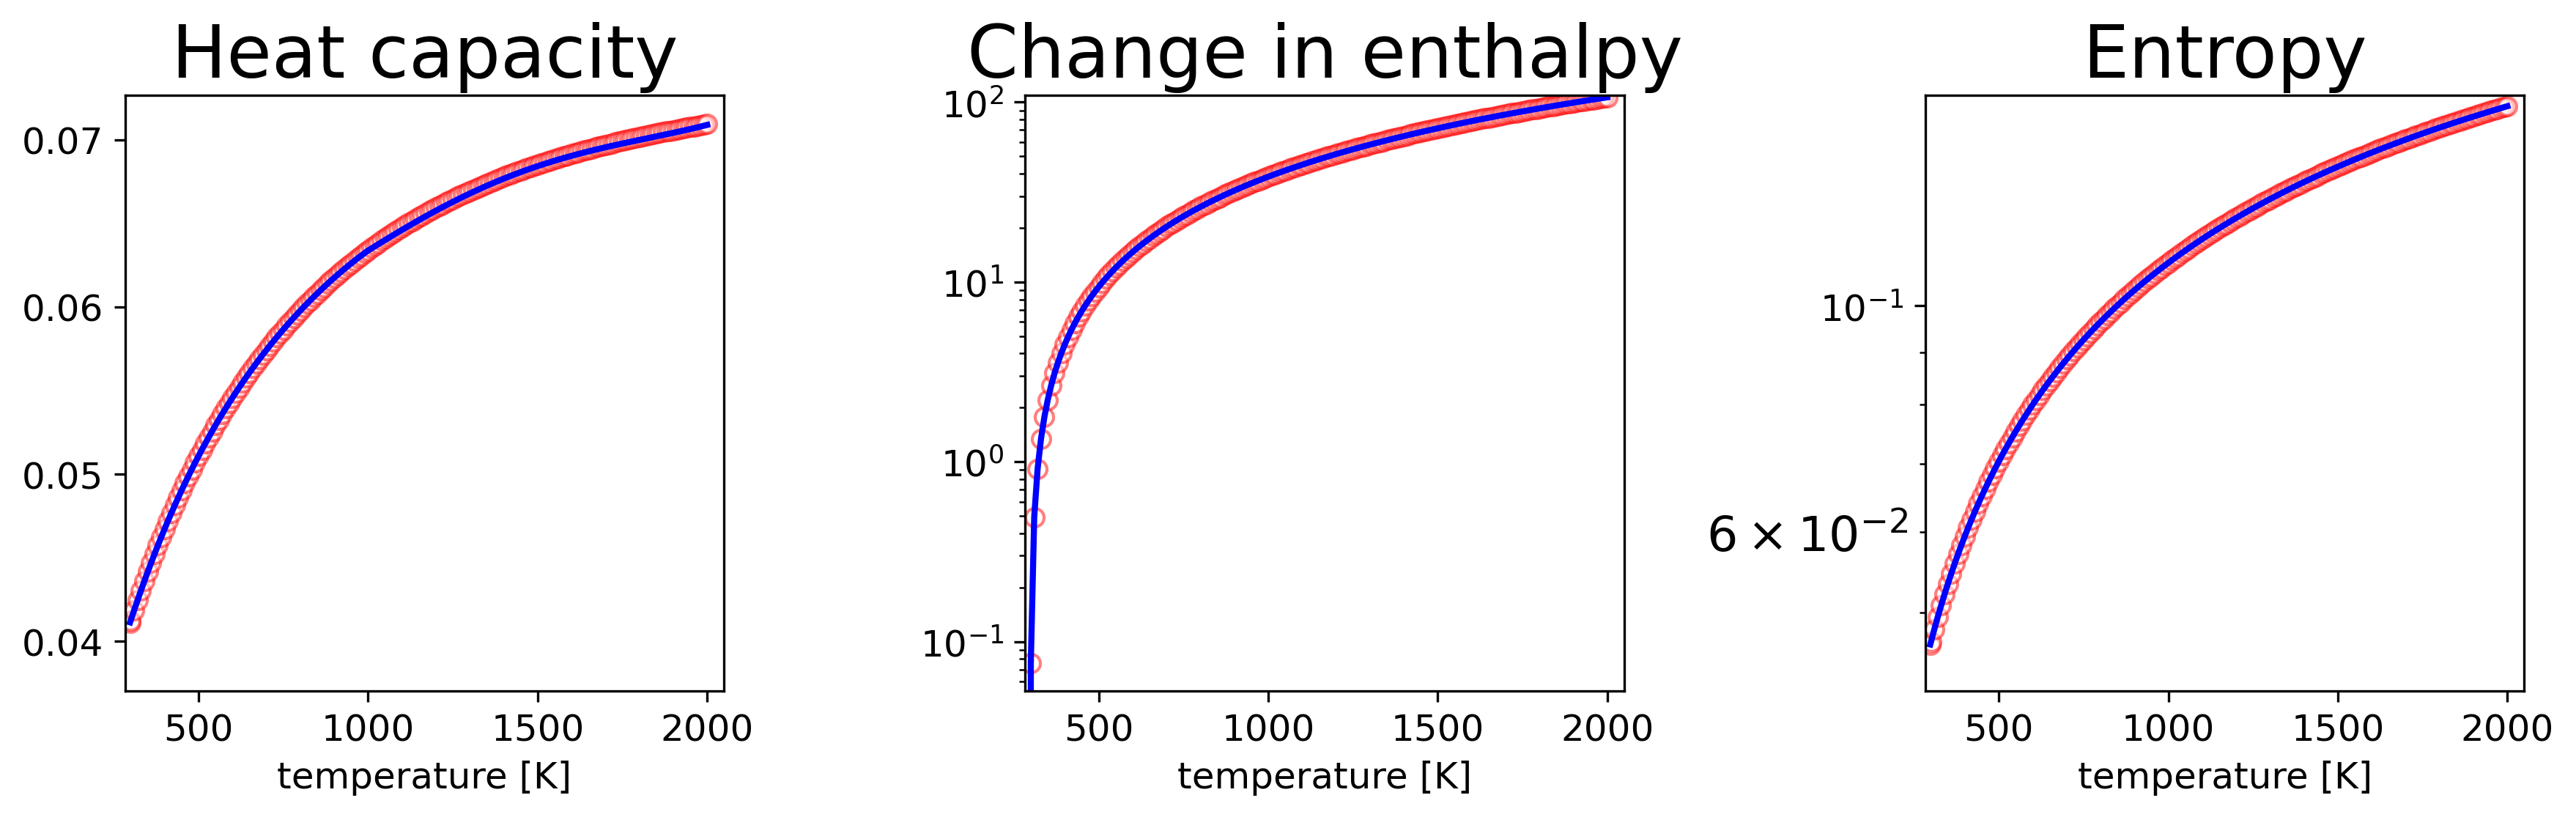

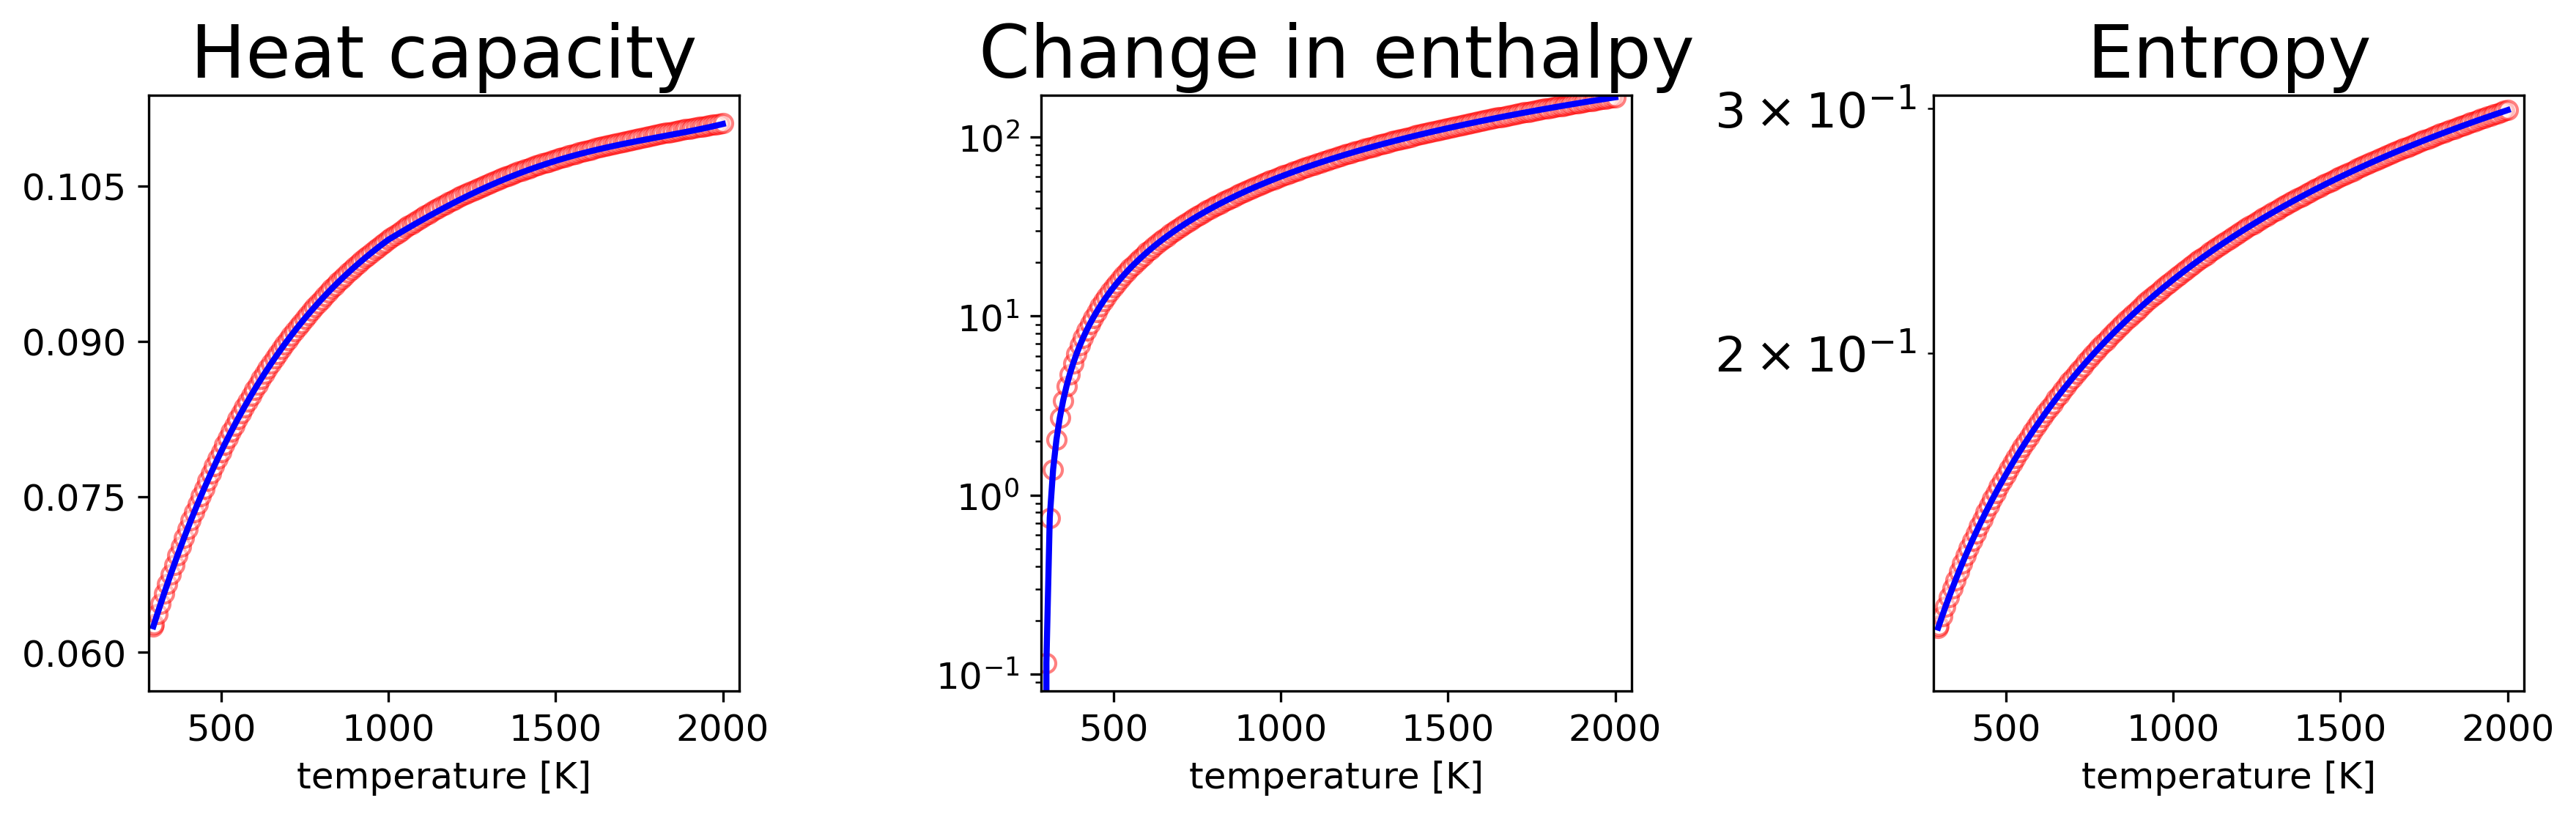

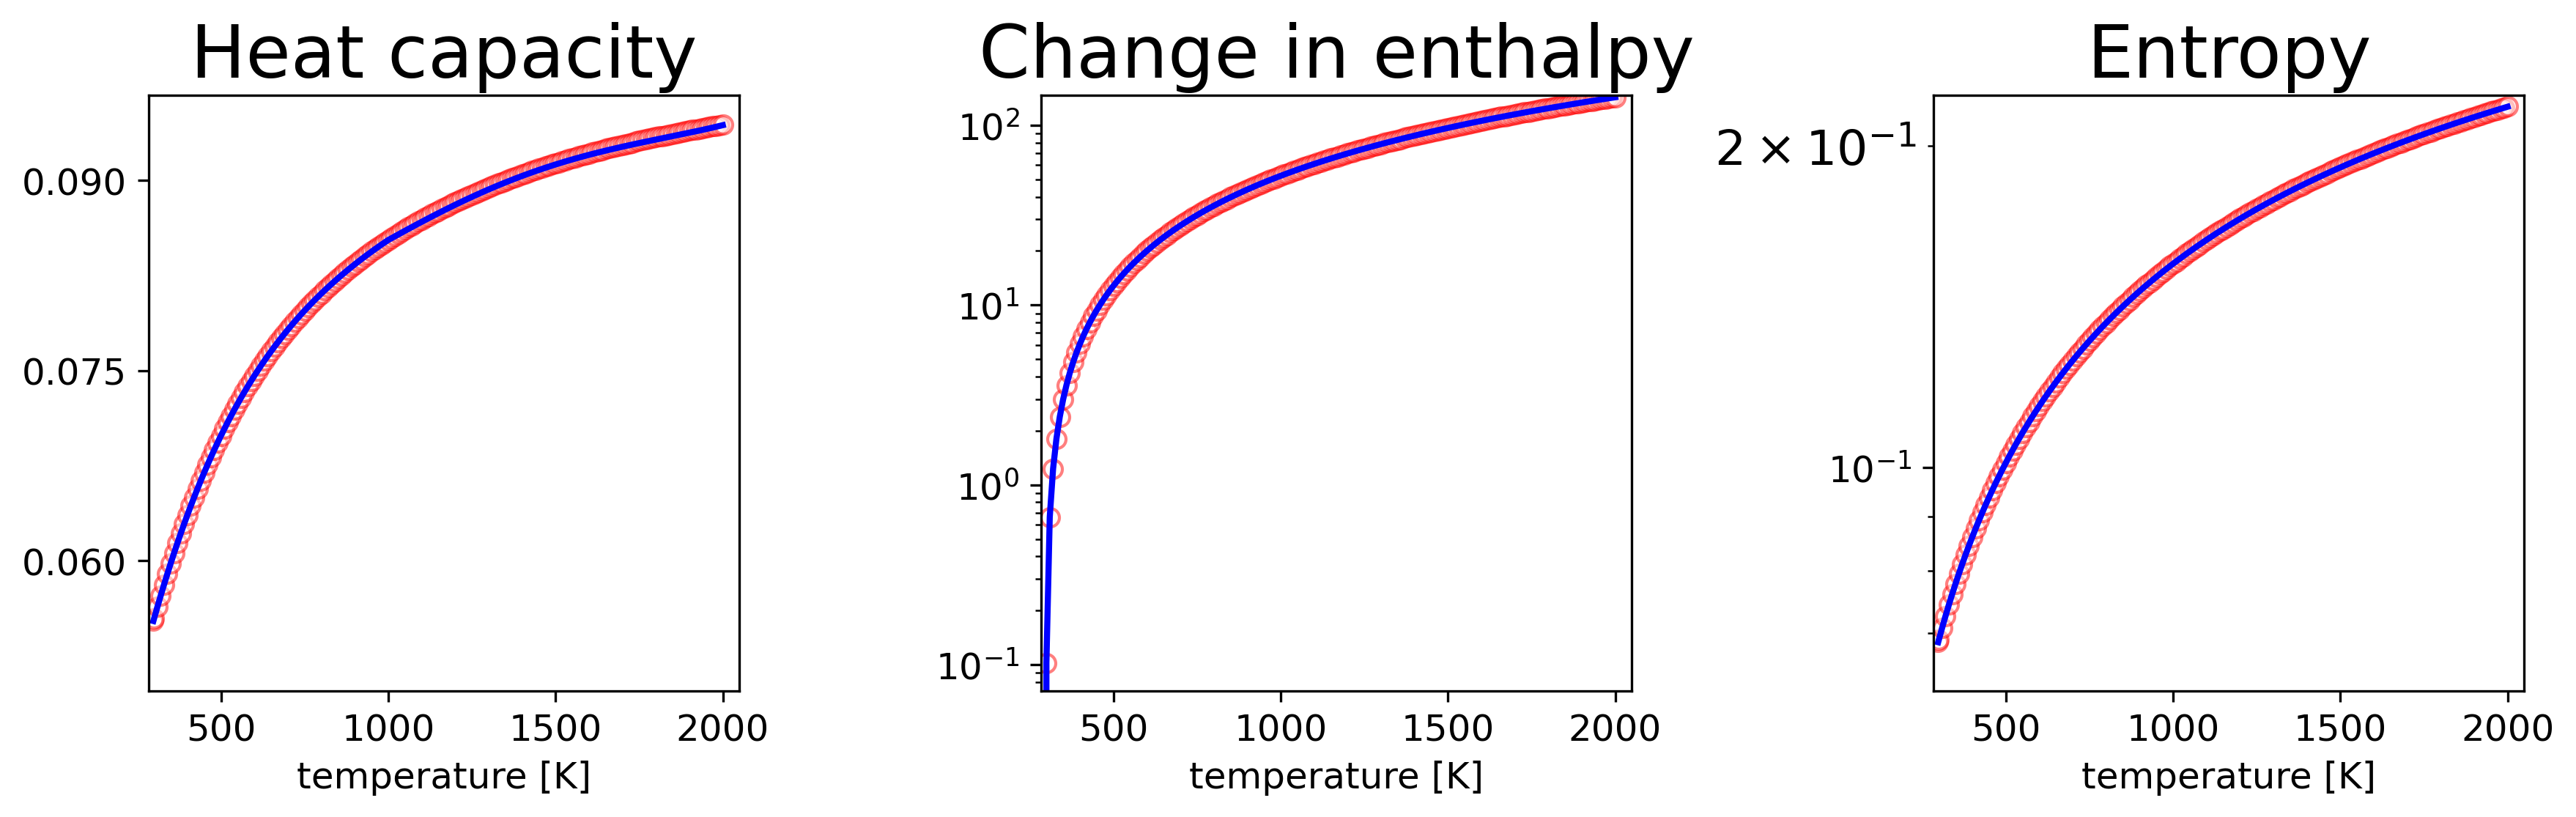

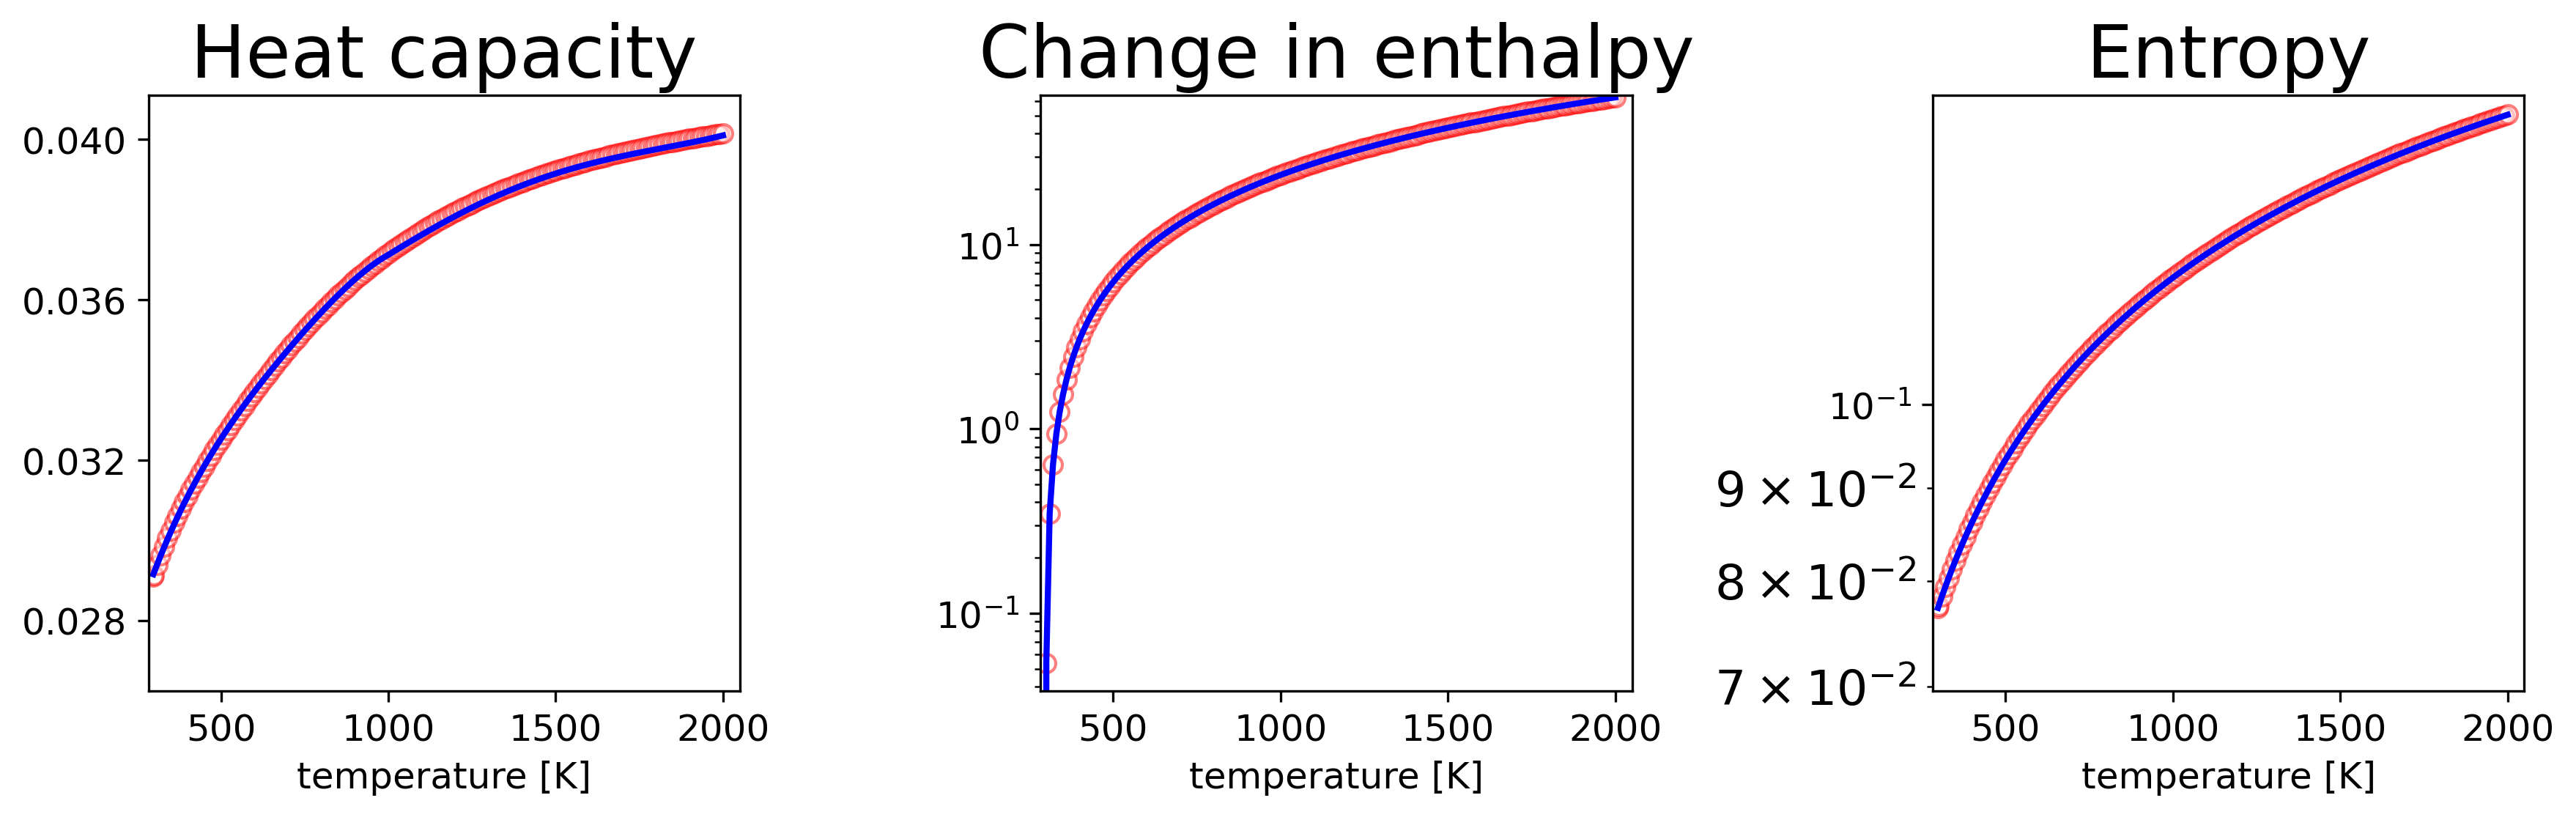

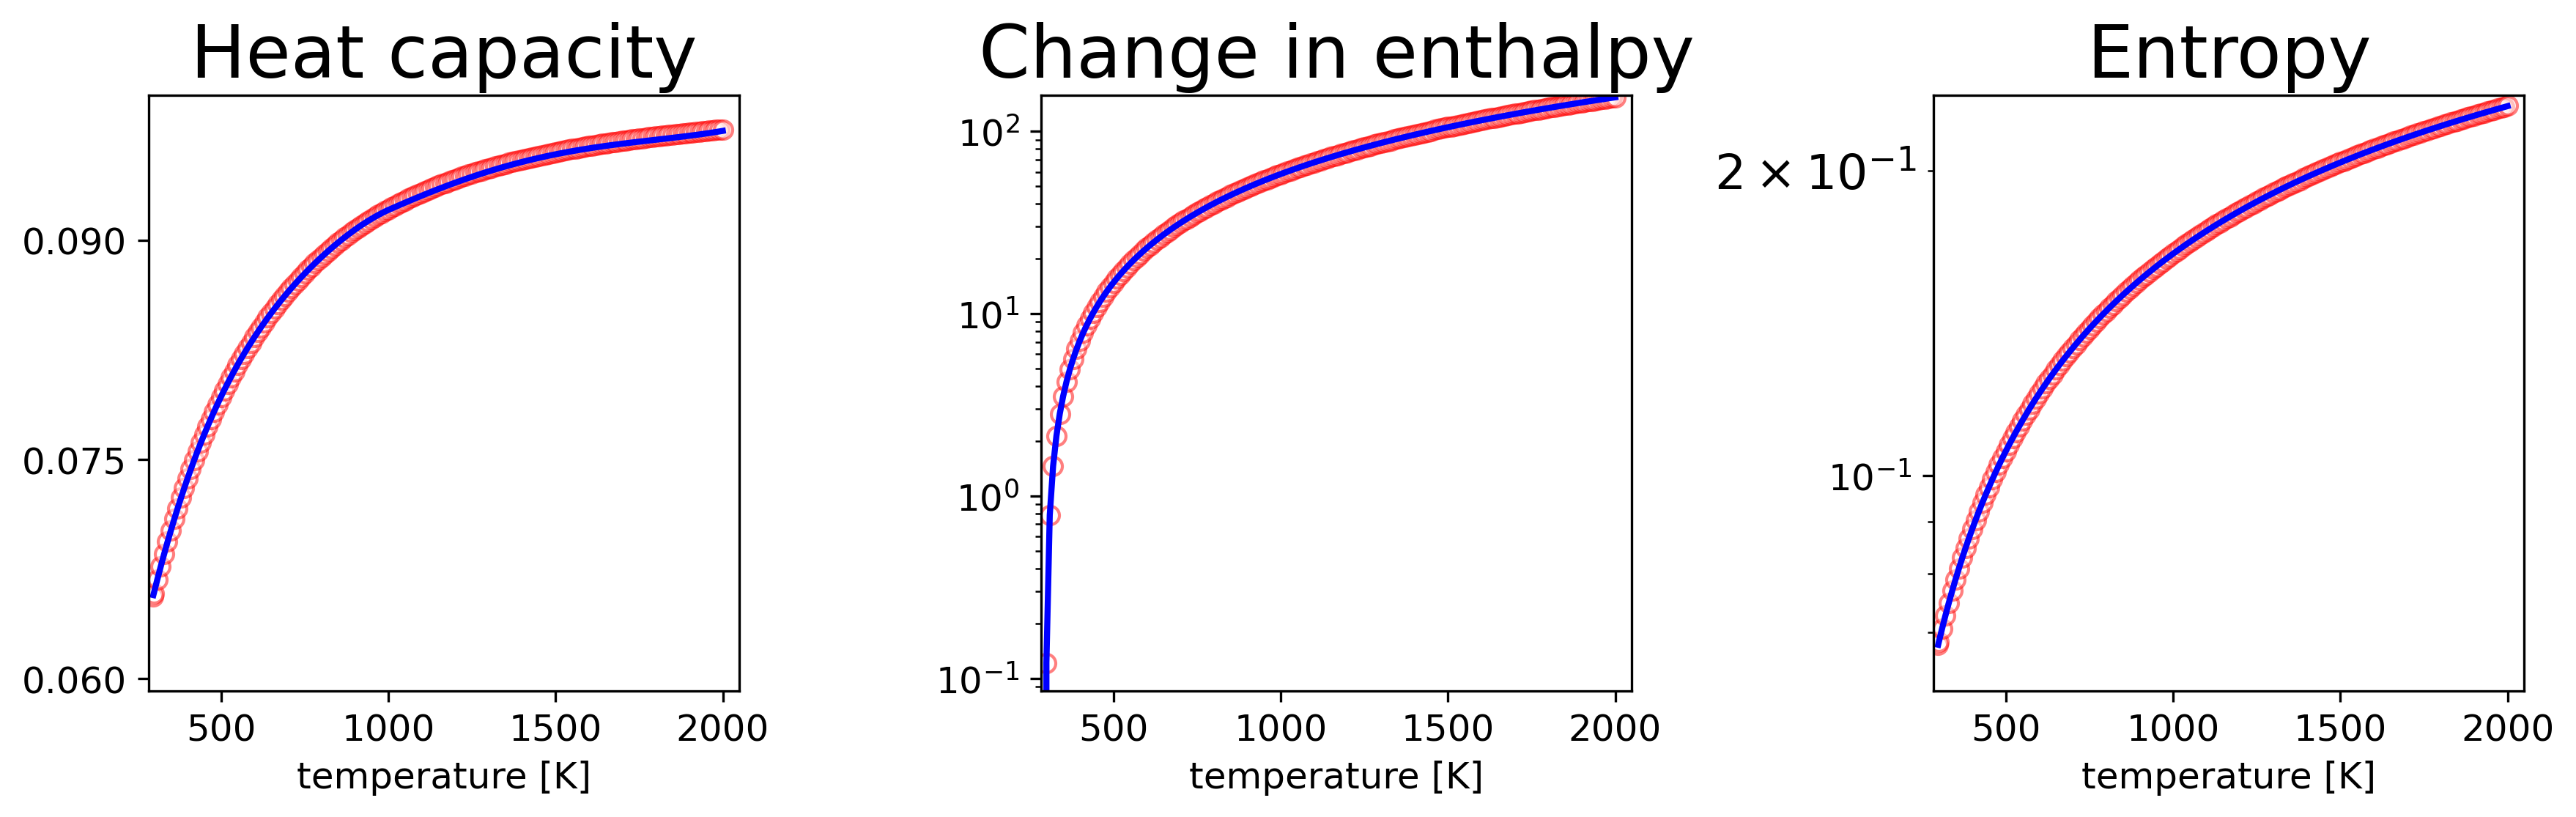

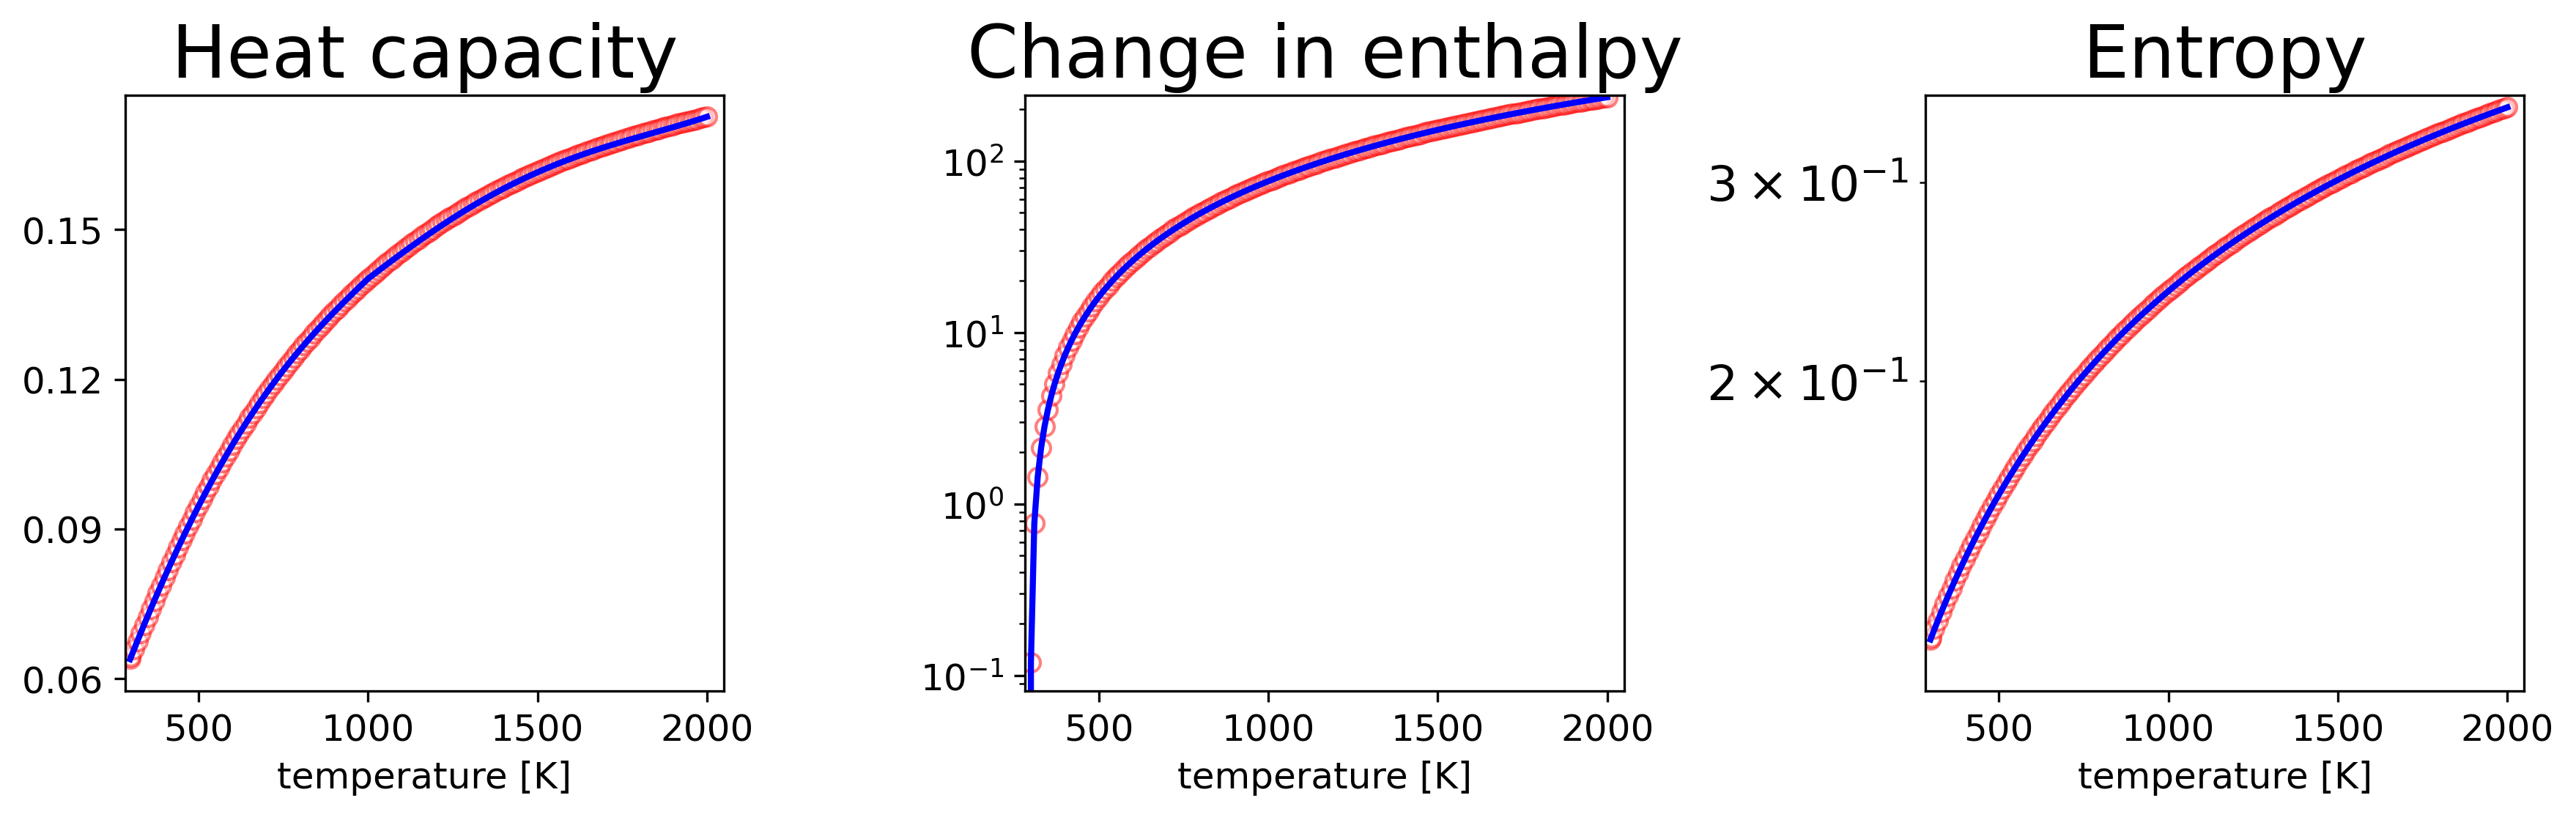

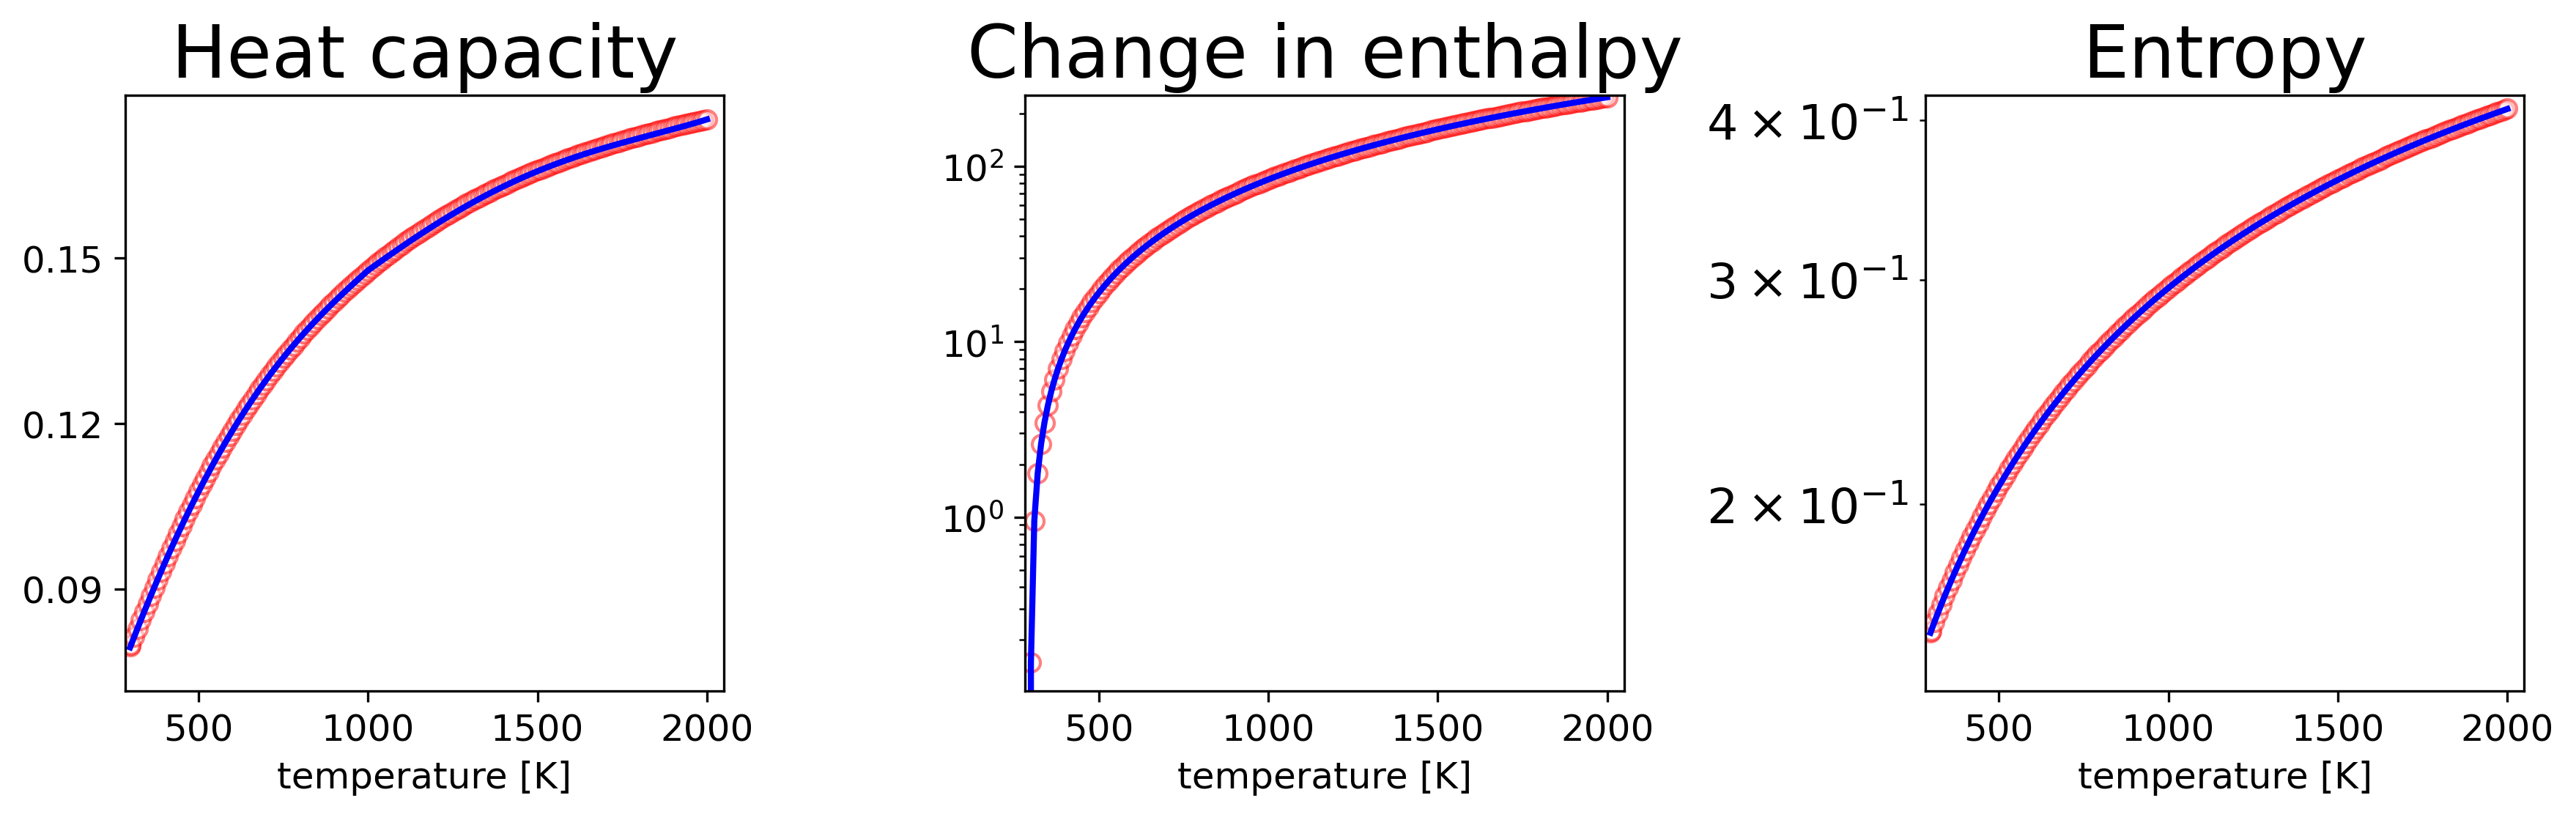

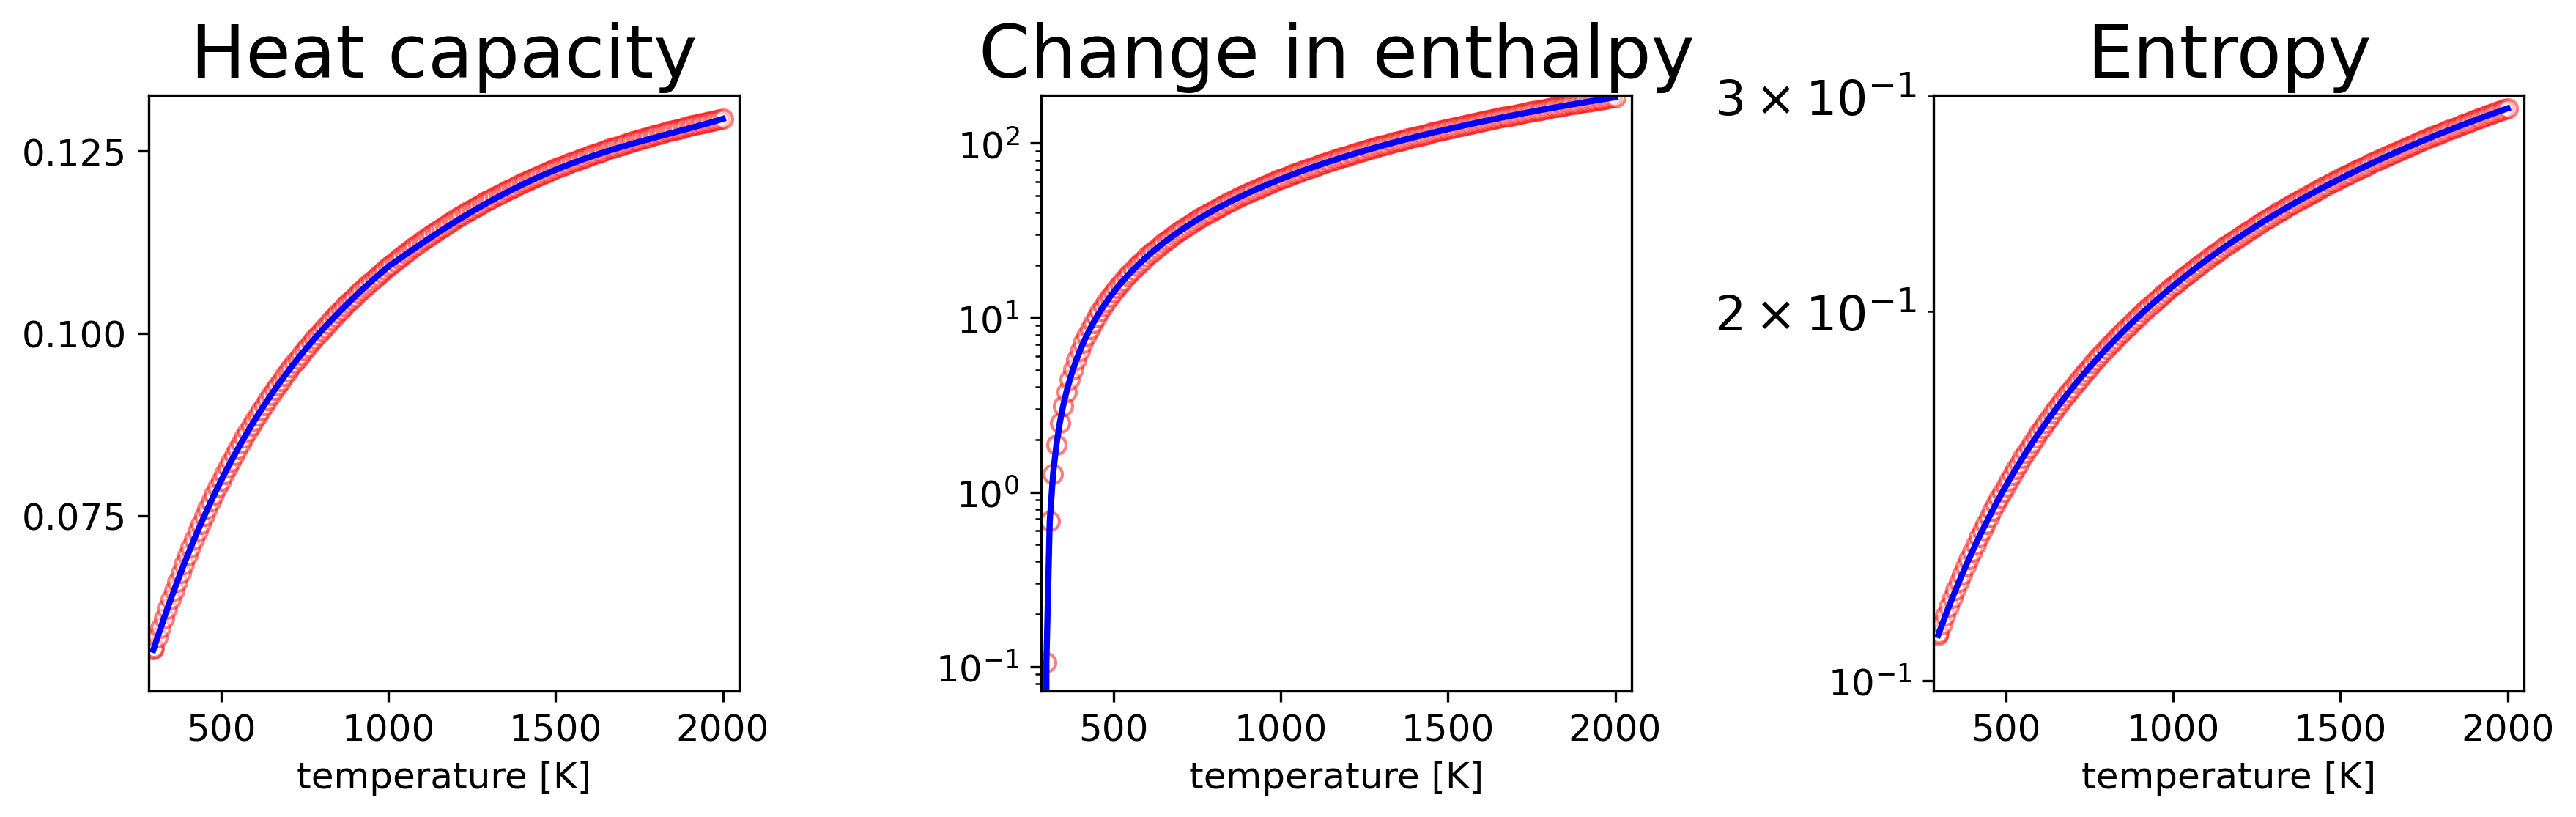

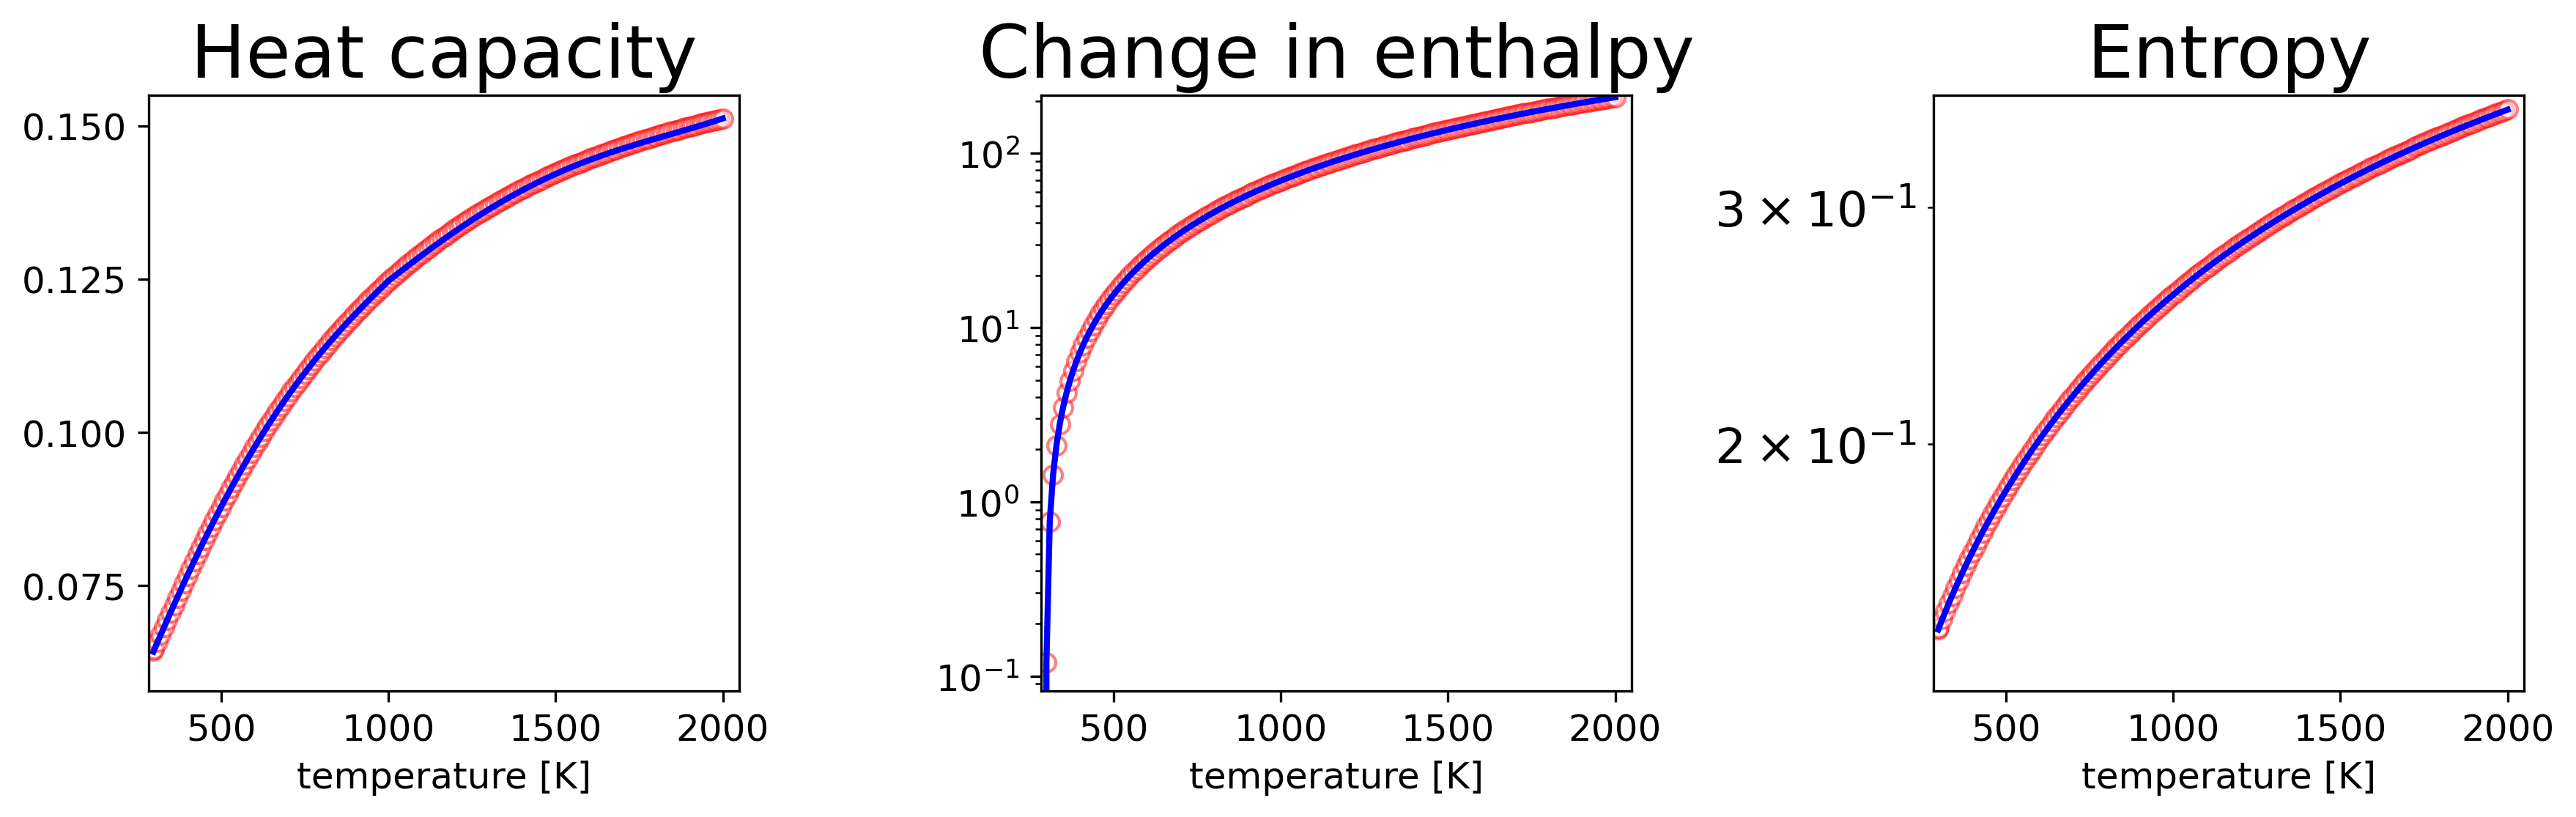

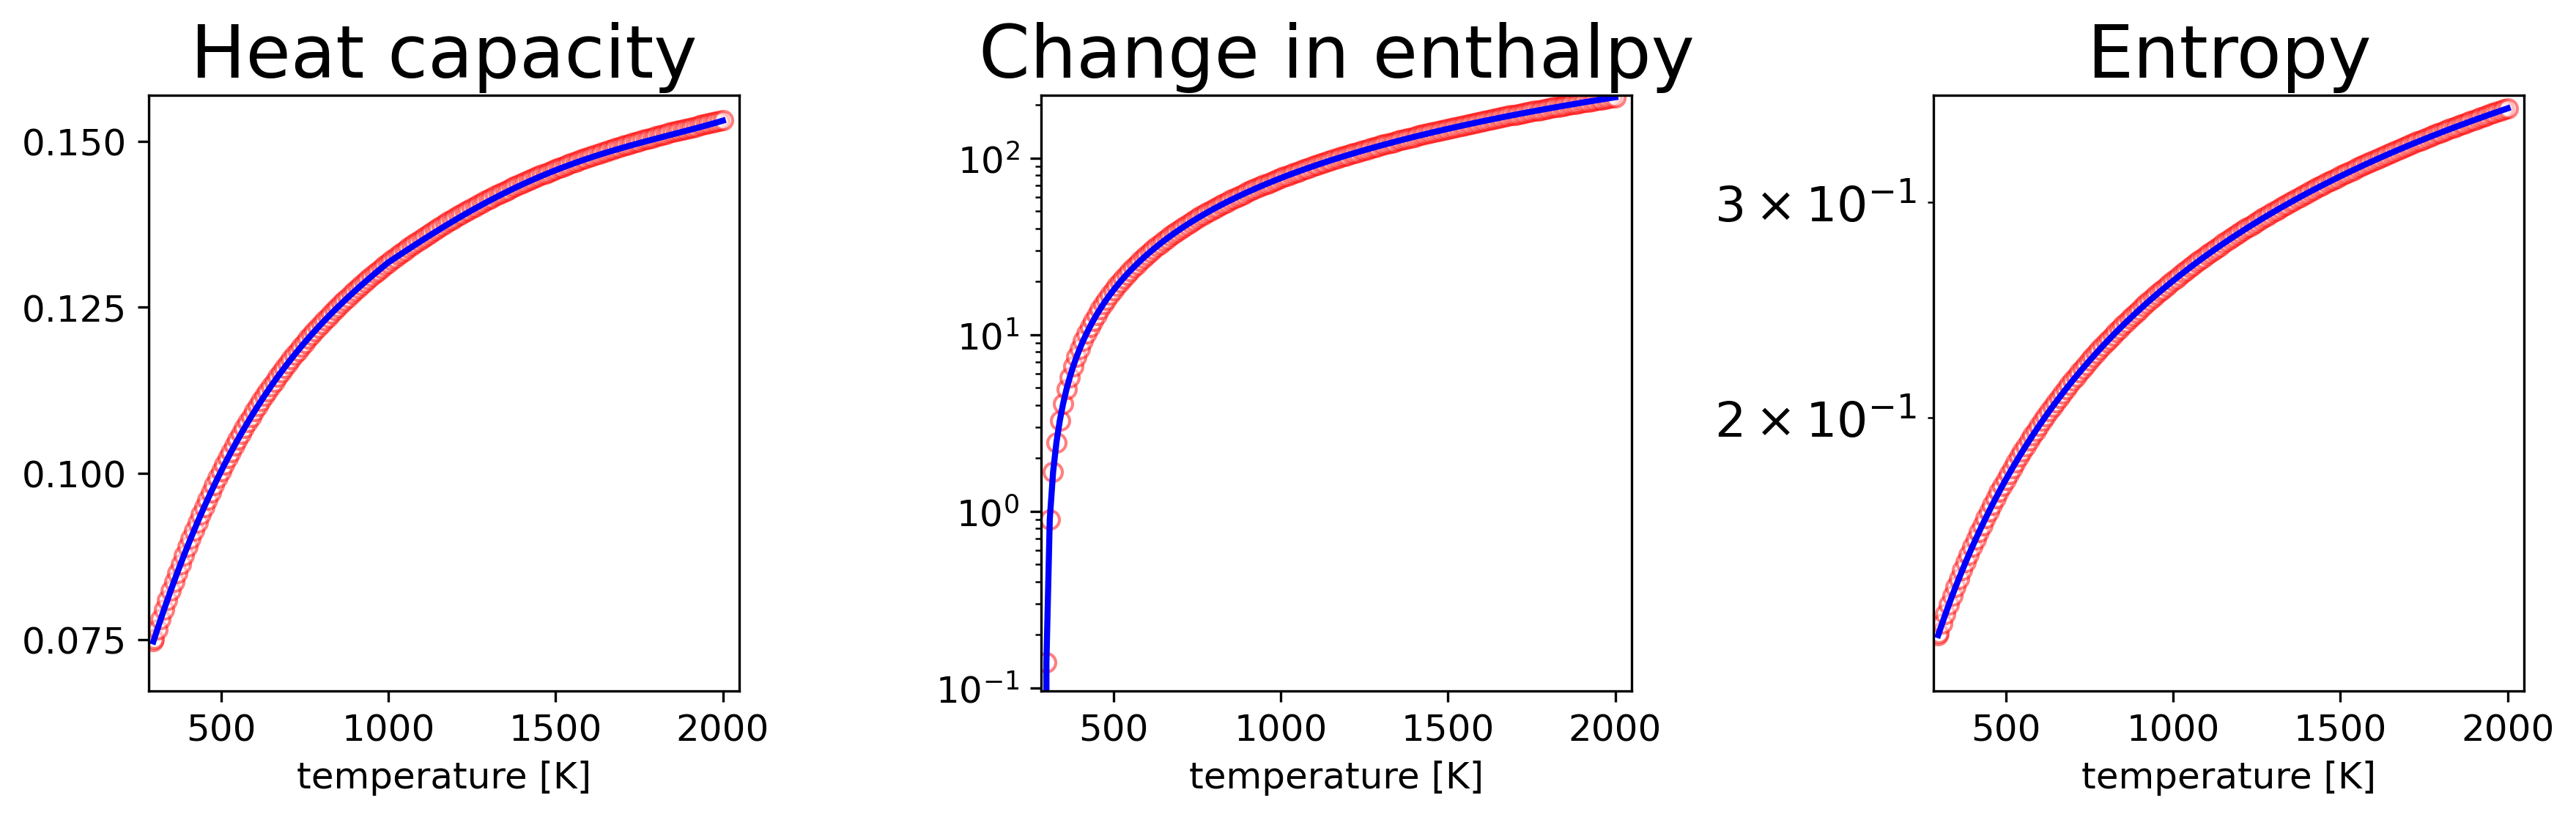

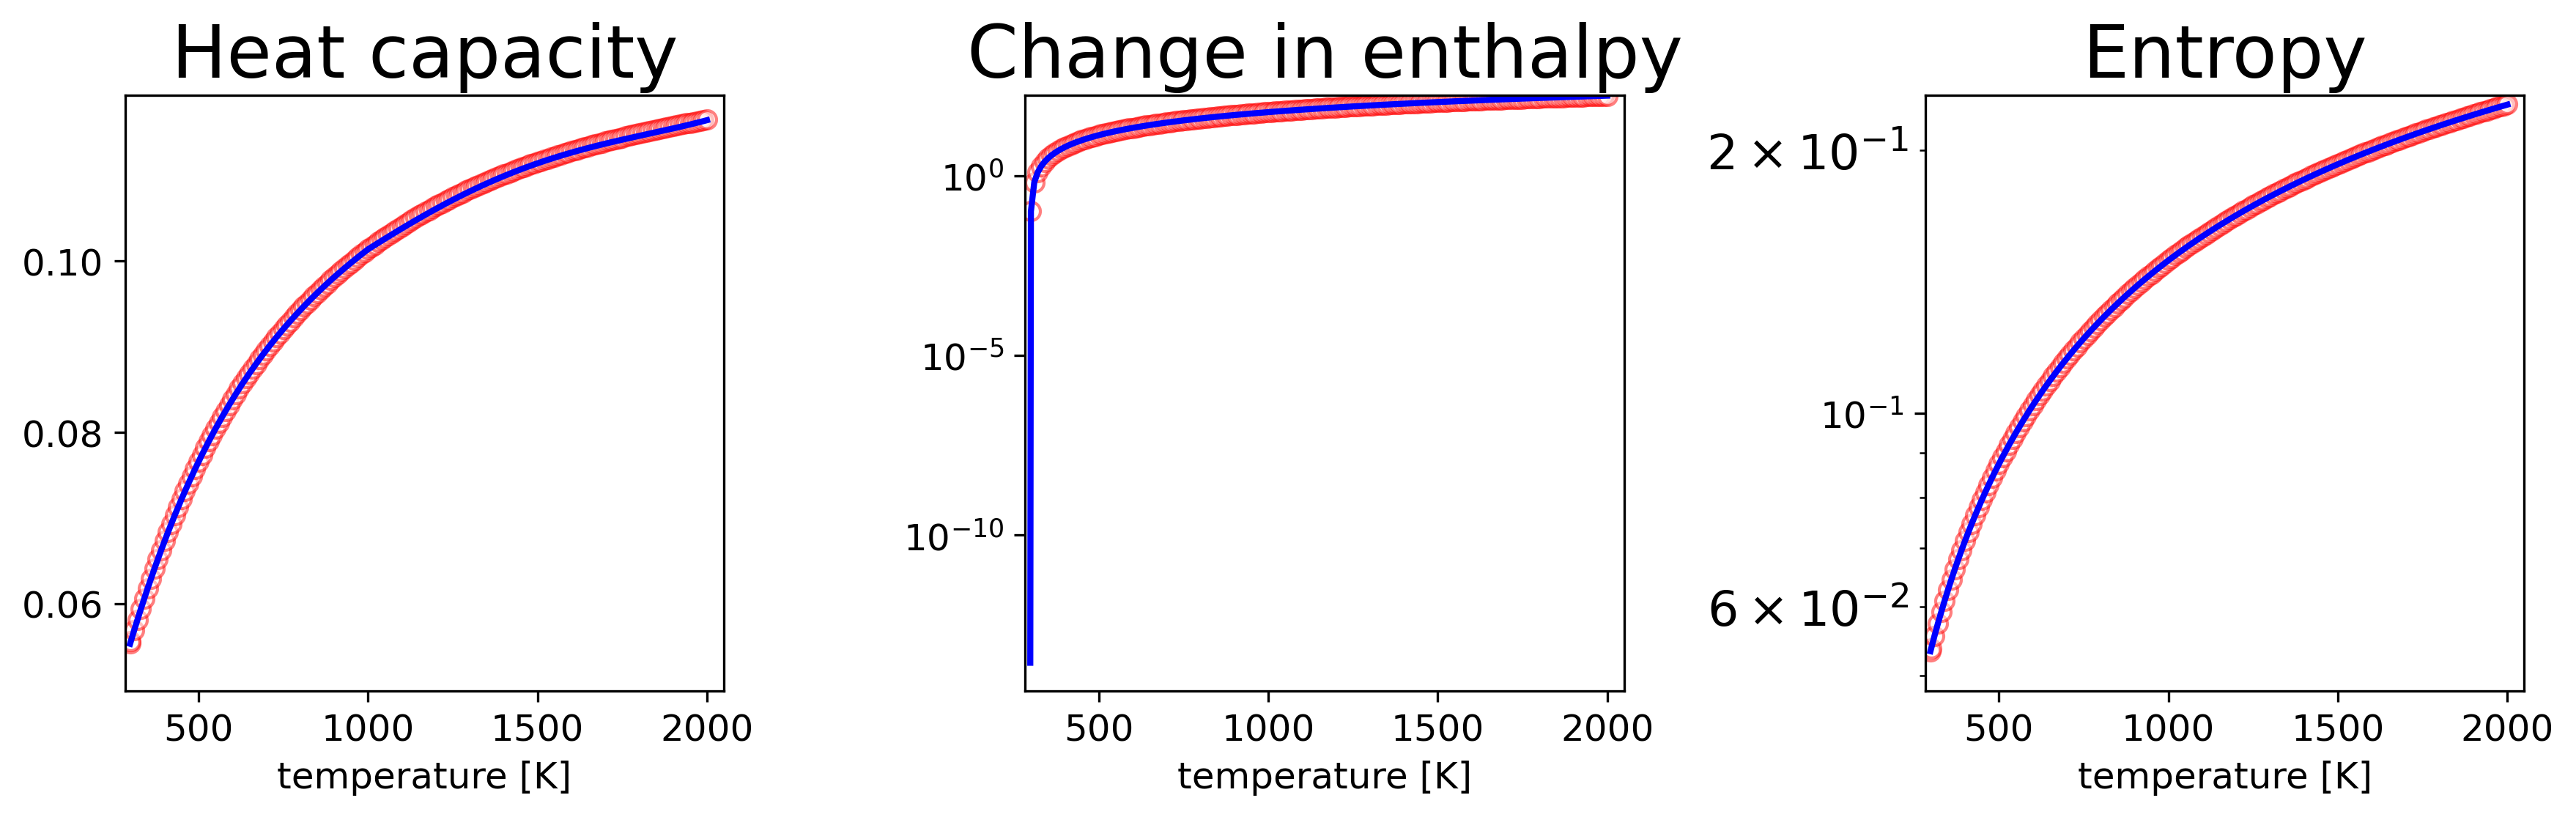

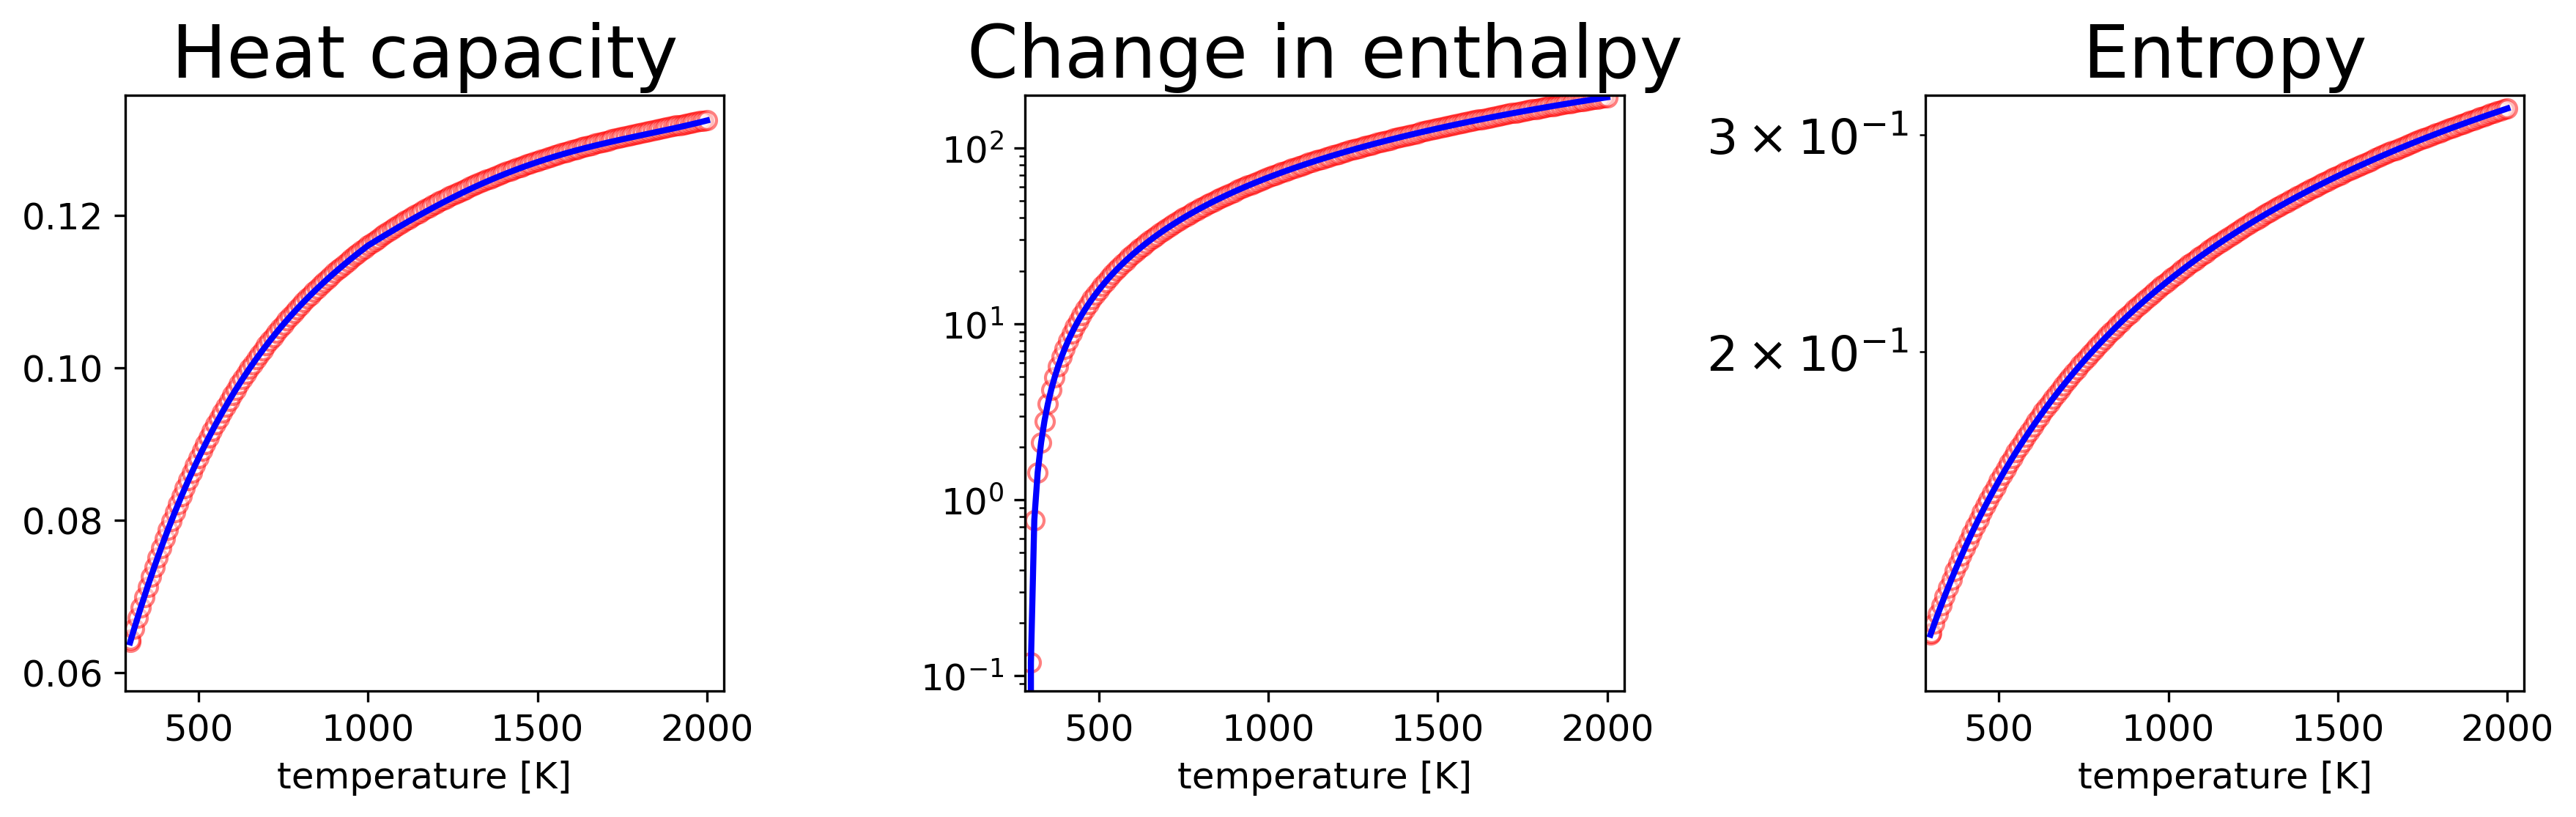

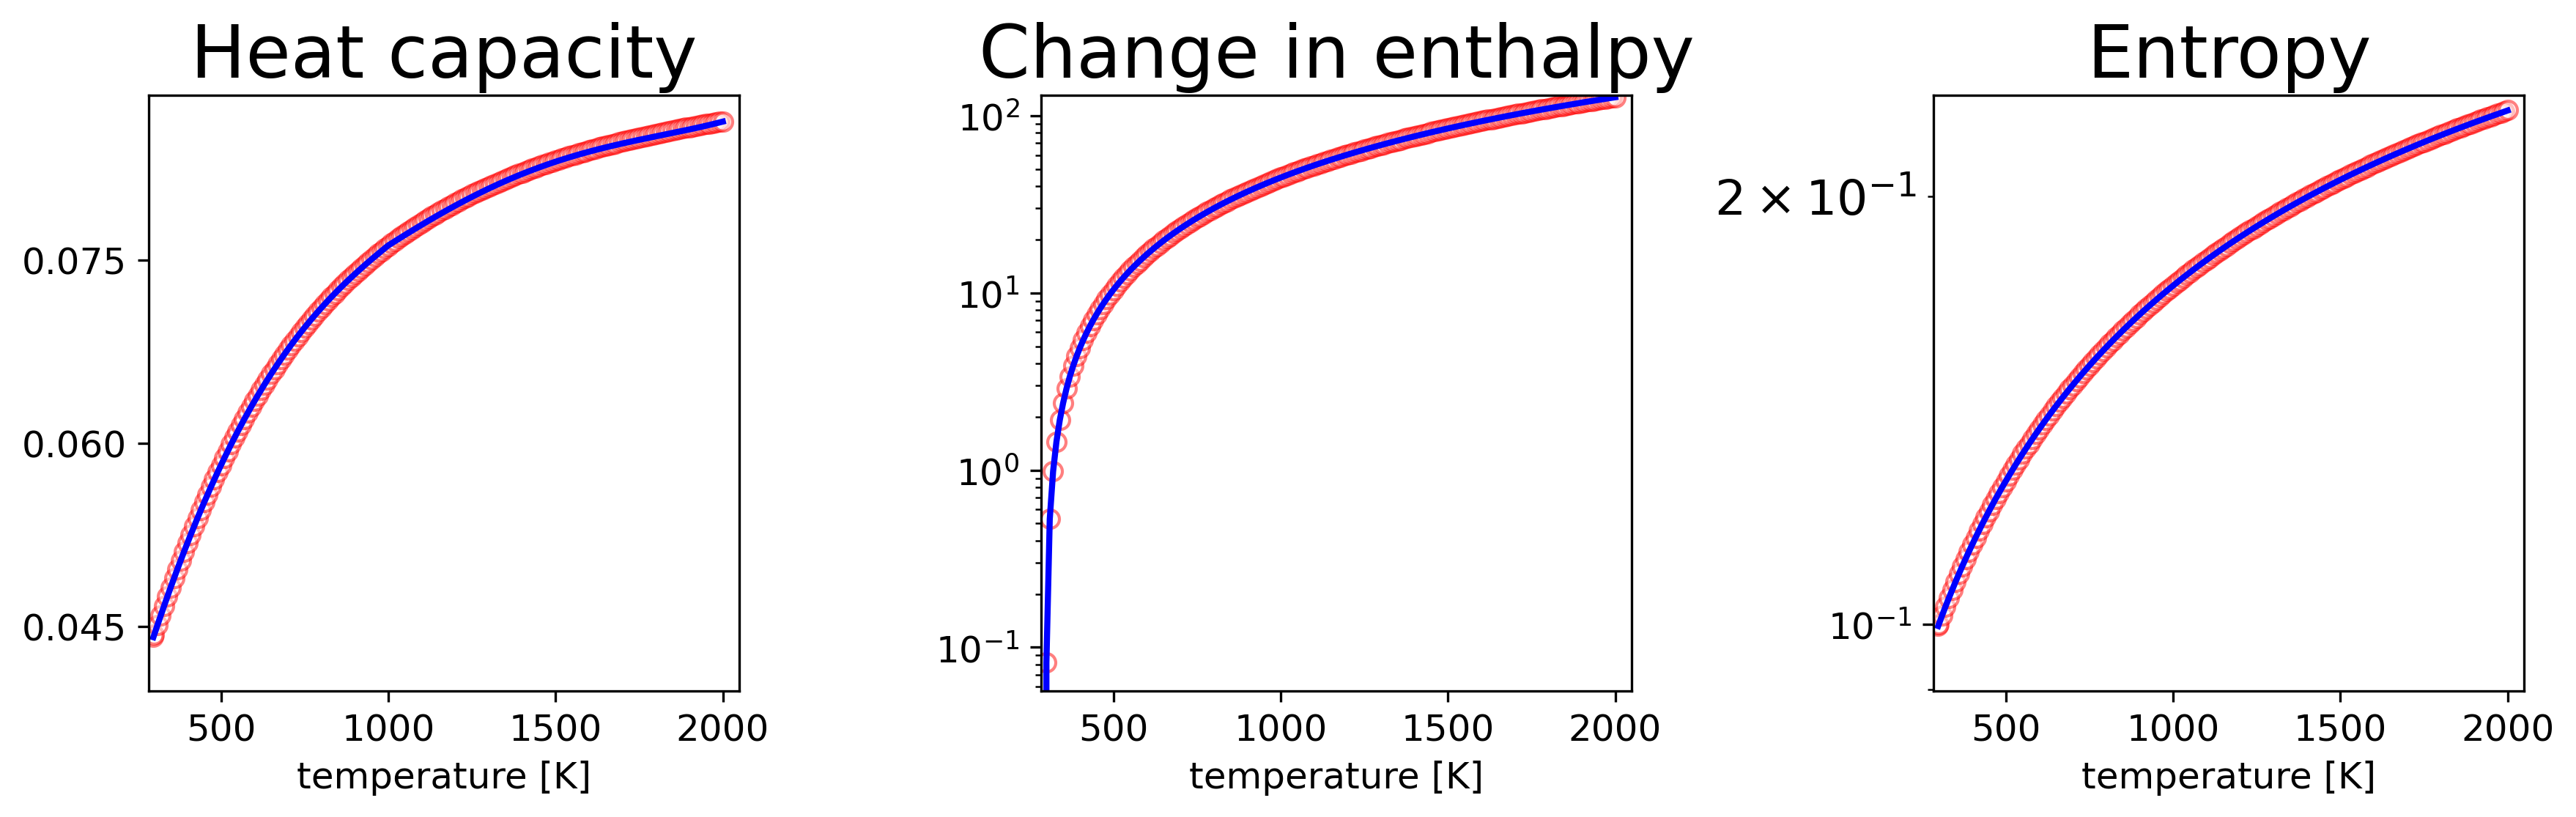

In [13]:
# create the array of temperatures in 10 degree increments
temperature = [298.15] #NOTE 298.15 must be first for the NASA polynomial routine to work!
T_low = 298.15
T_high = 2000.0
dT = 10.0 #temperature increment
temperature = np.append(temperature, np.arange(300.0, T_high+dT, dT))

list_of_species = 'sp_list.dat'
element = 'recalc_dft_sp'
info = open(list_of_species,'r')
species_list = info.readlines()
info.close()

new_output = open('dft_recalc.txt', 'w')

name_line = '\n'
species_line = '\n'

counter = -1
for species in species_list:
    counter += 1
    filename = species.strip()
    test = ig.Molecule()
    ig.parse_input_file(filename, test, element)
    ig.thermo(test, temperature)

    name_line += ' %s'%(test.name)
    if counter == 4:
        name_line +='\n'
        counter == -1
    species_line += test.species_lines

    ig.get_thermo_from_NASA(temperature, test)
    ig.compare_NASA_to_thermo(temperature, test)

name_line += '\n\n'
# new_output.write(name_line)
new_output.write(species_line)

new_output.close()

In [14]:
def update_long_desc(file_path):
    # Define the new longDesc content
    new_long_desc = (
        'Calculated by Torrie Asifor at Northeastern University using Statistical Mechanics. '
        'Based on DFT calculations by Colin Gallagher at Northeastern University'
    )

    # Read the original content from the file
    with open(file_path, 'r') as file:
        content = file.read()

    # Define a regex pattern to match the longDesc section
    pattern = re.compile(r'longDesc\s*=\s*u""".*?""",', re.DOTALL)

    # Replace the old longDesc with the new one
    updated_content = pattern.sub(f'longDesc = u"""{new_long_desc}""",', content)

    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(updated_content)

    print(f"Updated longDesc in {file_path}")

In [15]:
update_long_desc("dft_recalc.txt")

Updated longDesc in dft_recalc.txt


In [16]:
def convert_to_rmg_format(species_data, index):
    # Extract species name
    name_match = re.search(r'name = "(.+?)"', species_data)
    name = name_match.group(1) if name_match else "Unknown"
    print(name)

    # Extract thermo data
    thermo_str = re.findall(r'NASA\(\s*\[(\d+\.?\d*),\s*(\d+\.?\d*)\],\s*\[([^\]]+)\]\s*\),?', species_data)
    print(thermo_str)

    if len(thermo_str) != 2:
        raise ValueError("Thermo data does not contain two NASA polynomials")

    thermo_data = []
    for match in thermo_str:
        Tmin, Tmax, coeffs = match
        coeffs_list = [float(coeff) for coeff in coeffs.split(',')]
        thermo_data.append({
            "Tmin": Tmin,
            "Tmax": Tmax,
            "coeffs": coeffs_list
        })

    # Process thermo data to match the required format
    thermo_str = "thermo = NASA(\n    polynomials = [\n"
    for data in thermo_data:
        thermo_str += f"        NASAPolynomial(coeffs={data['coeffs']}, Tmin=({data['Tmin']}, 'K'), Tmax=({data['Tmax']}, 'K')),\n"
    thermo_str += f"    ],\n    Tmin=({thermo_data[0]['Tmin']}, 'K'),\n    Tmax=({thermo_data[1]['Tmax']}, 'K'),\n),"


    # Extract longDesc
    long_desc_match = re.search(r'longDesc = u"""(.+?)"""', species_data, re.DOTALL)
    long_desc = long_desc_match.group(1).strip() if long_desc_match else ""

    # Format for RMG
    rmg_format = f"""
entry(
    index = {index},
    label = "{name}",
    molecule =
\"\"\"
\"\"\",
    {thermo_str}
    shortDesc = u\"""{name}\""",
    longDesc =
u\"""{long_desc}
\""",
)
"""
    return rmg_format

In [17]:
def process_dft_recalc_file(input_file, output_file):
    with open(input_file, 'r') as infile:
        data = infile.read()

    # Split data into individual species
    species_list = re.split(r'\nspecies\(', data)
    # Remove the first empty element if it exists
    if not species_list[0].strip():
        species_list = species_list[1:]

    entries = []
    for idx, species_data in enumerate(species_list):
        if species_data.strip():  # Skip empty entries
            entry = convert_to_rmg_format(species_data, idx)
            entries.append(entry)

    with open(output_file, 'w') as outfile:
        for entry in entries:
            outfile.write(entry)
            outfile.write('\n')  # Add space between species entries

In [18]:
input_file = 'dft_recalc.txt'
output_file = 'CO2RR_Adsorbates_Cu3Sn0001.py'
process_dft_recalc_file(input_file, output_file)

CHOX
[('298.0', '1000.0', '1.74349313E+00, 1.48300711E-02,\n \t\t -1.65536121E-05, 1.03768953E-08, -2.77422703E-12,\n \t\t -1.40682838E+04, -8.10961736E+00'), ('1000.0', '2000.0', '7.60674062E+00, -3.96066968E-03,\n \t\t 7.15100332E-06, -3.87857554E-09, 7.04121665E-13,\n \t\t -1.55695014E+04, -3.77908267E+01')]
COCHOX
[('298.0', '1000.0', '2.51074428E+00, 2.20340273E-02,\n \t\t -2.02688214E-05, 9.54750791E-09, -1.82176149E-12,\n \t\t -3.07658755E+04, -4.81098828E+00'), ('1000.0', '2000.0', '1.19774317E+01, -6.19101430E-03,\n \t\t 1.12437071E-05, -6.15372406E-09, 1.12529604E-12,\n \t\t -3.32883219E+04, -5.32387915E+01')]
COOHX
[('298.0', '1000.0', '1.57291532E+00, 2.39770732E-02,\n \t\t -2.79387799E-05, 1.65750947E-08, -3.92695945E-12,\n \t\t -4.88082078E+04, -6.75263460E+00'), ('1000.0', '2000.0', '1.02432721E+01, -4.50920480E-03,\n \t\t 8.09079692E-06, -4.35111478E-09, 7.85594402E-13,\n \t\t -5.09562429E+04, -5.03765829E+01')]
COX
[('298.0', '1000.0', '2.15374115E+00, 7.11964156E-03,\